# 🐕 RAG Dog Breed Analyzer - Step-by-Step Demo

## Task Overview and Methodology

This notebook demonstrates:

- Building a **multimodal RAG** pipeline (text + images)
- Comparing **RAG vs direct LLM** outputs
- Applying **cross-encoder reranking** for two-stage retrieval
- Testing and comparing **chunking strategies**
- Running quantitative local evaluation metrics (no RAGAS dependency)
- Visualizing retrieval quality and embedding candidate spaces (3D scatter/radar)

References:

- Retrieval-Augmented Generation (RAG) learning materials from course
- Two-stage retrieval with reranking (Kaggle reference)
- RAG chunking method references provided in homework
- - Ollama documentation: https://ollama.com/

Goals:

- Implement a document analysis app on a GenAI framework
- Extract structured insights from dog breed data
- Visualize quality and retrieval behavior (charts/plots)
- Validate output quality with quantitative retrieval/answer metrics
- Include robust CSV sanity/security checks and edge-case handling


### Datasets Used

- **Dog Breeds General Dataset (tabular, no images):**  
  https://www.kaggle.com/datasets/marshuu/dog-breeds
- **Expanded Ranking CSV Dataset:**  
  https://www.kaggle.com/datasets/jainaru/dog-breeds-ranking-best-to-worst
- **Dog Breeds Image Dataset:**  
  https://www.kaggle.com/datasets/darshanthakare/dog-breeds-image-dataset
- **Second Demonstration Dataset (Stanford Dogs):**  
  https://www.kaggle.com/datasets/jessicali9530/stanford-dogs-dataset

### Table of Contents

- Installation Steps
- 1) Setup and Configuration
- 2) Document Processing and Chunking
- 3) Demo 1: Family Dogs Query (RAG vs No-RAG)
- 4) Demo 2: Nami Multimodal Retrieval
- 5) Simple Evaluation Metrics
- 6) Embedding Space Visualizations
- Summary and Next Steps

> Note:
> All outputs are expected to appear below their corresponding code cells.
> If you cannot run model-dependent cells locally, review the code and markdown explanations to understand the full workflow.

## Installation Steps

Install Python 3.x:

```bash
python3 --version
```

Install JupyterLab:

```bash
pip3 install jupyterlab
```

Install project dependencies:

```bash
pip3 install -r requirements.txt
pip3 install langchain langchain-ollama
```

Install and run Ollama:

```bash
# Install from https://ollama.com/download
ollama serve
```

Pull required models:

```bash
ollama pull llama3.2
ollama pull llava
ollama pull nomic-embed-text
```

Start notebook:

```bash
jupyter lab
```




---
## 1️⃣ Setup and Configuration



In [1]:
# Reduce noisy logs and warnings (run before loading models)
import os
import logging
import warnings
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"

warnings.filterwarnings("ignore")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

for name in [
    "httpx",
    "urllib3",
    "sentence_transformers",
    "transformers",
    "huggingface_hub",
    "huggingface_hub.utils._http",
    "chromadb",
    "document_processor",
    "rag_engine",
    "src.rag_engine",
]:
    logging.getLogger(name).setLevel(logging.ERROR)

logging.getLogger().setLevel(logging.ERROR)
"Logging set to minimal output"


'Logging set to minimal output'

In [2]:
# -----------------------------------------------------------------------------
# Homework compliance checklist (implemented in this notebook)
# - GenAI framework/app: Ollama + end-to-end RAG pipeline
# - Document analysis + extraction + visualization: tables, comparisons, radar, 3D scatter
# - Chunking: multiple strategies implemented and compared
# - Reranking: cross-encoder reranking after vector retrieval
# - Evaluation: small evaluation set with quantitative local metrics (Hit@k, Precision@k, etc.)
# - Multimodal demo: Nami example (vision signal + retrieved context)
# -----------------------------------------------------------------------------

# Import required libraries
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
import requests
from PIL import Image
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Add src to path
sys.path.append('./src')

from src.config import (
    PROJECT_ROOT, DATA_DIR, OLLAMA_CONFIG, MODELS,
    CHUNKING_STRATEGIES, RETRIEVAL_CONFIG
)
from src.document_processor import DocumentProcessor
from src.rag_engine import RAGEngine
from src.data_validator import validate_base_and_ranking
from src.visualizer import RAGVisualizer

print("✓ All imports successful")

# Test Ollama connection
try:
    response = requests.get(f"{OLLAMA_CONFIG['base_url']}/api/tags", timeout=10)
    response.raise_for_status()
    models = [m['name'] for m in response.json().get('models', [])]
    print(f"✓ Ollama connection: OK")
    print(f"✓ Available models: {models}")
except Exception as e:
    print(f"❌ Ollama error: {e}")
    "Make sure to run: ollama serve"




✓ All imports successful
✓ Ollama connection: OK
✓ Available models: ['nomic-embed-text:latest', 'llava:latest', 'llama3.2:latest', 'llama3:latest']


In [3]:
import sys
print(sys.version)
print(sys.executable)


3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
/Users/Denise_Mendez/Documents/ai_architecture_github/rag-document-analyzer/.venv312/bin/python


---
## 2️⃣ Document Processing & Chunking

### Understanding Chunking Strategies

We compare 3 different chunking approaches:
1. **Fixed-size**: Approx token chunks (512 size, 50 overlap)
2. **Semantic**: Sentence-aware splitting from breed attribute statements
3. **Combined**: One multimodal chunk with text + image metadata




In [4]:
# Load datasets + run sanity checks
from IPython.display import HTML, display

# Wider display settings for notebook previews
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 400)

base_csv_path = DATA_DIR / "documents" / "dog_breeds.csv"
ranking_csv_path = DATA_DIR / "documents" / "dogs-ranking-dataset.csv"

df = pd.read_csv(base_csv_path)
ranking_df = pd.read_csv(ranking_csv_path)

print(f"📊 Base dataset loaded: {len(df)} breeds")
print(f"📊 Ranking dataset loaded: {len(ranking_df)} rows")

validation = validate_base_and_ranking(df, ranking_df)
validation_summary = pd.DataFrame([
    {
        'dataset': name,
        'rows': info['rows'],
        'columns': len(info['columns']),
        'schema_ok': info['is_valid_schema'],
        'missing_required_columns': ', '.join(info['missing_required_columns']) or 'None',
        'duplicate_rows': info['duplicate_rows'],
        'duplicate_breed_values': info['duplicate_breed_values'],
        'null_columns': len(info['null_counts']),
        'formula_risk_columns': len(info['formula_risk_cells']),
    }
    for name, info in validation.items()
])

def show_wide_table(df_view, title):
    print(f"\n{title}")
    html = df_view.to_html(index=False)
    html = html.replace('<table border="1" class="dataframe">', '<table style="table-layout:auto; width:2200px; font-size:12px;">')
    html = html.replace('<th>', '<th style="padding:8px 10px; white-space:nowrap; border:1px solid #ddd; background:#f8f9fa;">')
    html = html.replace('<td>', '<td style="padding:8px 10px; white-space:normal; vertical-align:top; border:1px solid #ddd;">')
    display(HTML(f'<div style="width:100%; overflow-x:auto;">{html}</div>'))

show_wide_table(validation_summary, "CSV sanity check summary:")
show_wide_table(df.head(15), "Base dataset preview (first 15 rows):")
show_wide_table(ranking_df.head(15), "Ranking dataset preview (first 15 rows):")



📊 Base dataset loaded: 117 breeds
📊 Ranking dataset loaded: 87 rows

CSV sanity check summary:


dataset,rows,columns,schema_ok,missing_required_columns,duplicate_rows,duplicate_breed_values,null_columns,formula_risk_columns
base_csv,117,8,True,None,0,14,0,0
ranking_csv,87,19,True,None,0,0,0,0



Base dataset preview (first 15 rows):


Breed,Country of Origin,Fur Color,Height (in),Color of Eyes,Longevity (yrs),Character Traits,Common Health Problems
Labrador Retriever,Canada,"Yellow, Black, Chocolate",21-24,Brown,10-12,"Loyal, friendly, intelligent, energetic, good-natured","Hip dysplasia, obesity, ear infections"
German Shepherd,Germany,"Black, Tan",22-26,Brown,7-10,"Loyal, intelligent, protective, confident, trainable","Hip dysplasia, elbow dysplasia, pancreatitis"
Bulldog,England,"White, Red",12-16,Brown,8-10,"Loyal, calm, gentle, brave","Skin allergies, respiratory issues, obesity"
Poodle,France,"White, Black, Brown, Apricot",10-15,"Brown, Blue",12-15,"Intelligent, active, affectionate, hypoallergenic","Hip dysplasia, epilepsy, bladder stones"
Beagle,England,"White, Tan, Red, Lemon",13-15,Brown,12-15,"Curious, friendly, energetic, good-natured","Ear infections, hip dysplasia, epilepsy"
Chihuahua,Mexico,"Black, Brown, Tan, White",6-9,"Brown, Blue",12-20,"Loyal, energetic, confident, sensitive","Dental problems, eye issues, respiratory issues"
Boxer,Germany,"Fawn, Brindle",21-25,Brown,10-12,"Loyal, energetic, intelligent, playful, protective","Hip dysplasia, cancer, heart conditions"
Golden Retriever,Scotland,Golden,21-24,Brown,10-12,"Intelligent, friendly, kind, loyal, good-natured","Hip dysplasia, cancer, skin allergies"
Pug,China,"Fawn, Black",10-14,Brown,12-15,"Loyal, playful, affectionate, social, charming","Eye problems, respiratory issues, obesity"
Rottweiler,Germany,"Black, Tan",22-27,Brown,8-10,"Loyal, protective, confident, strong","Hip dysplasia, cancer, elbow dysplasia"



Ranking dataset preview (first 15 rows):


Breed,type,score,popularity ranking,size,intelligence,congential ailments,score for kids,size.1,$LIFETIME COST,INTELLIGENCE RANK,INTELLIGENCE %,LONGEVITY(YEARS),NUMBER OF GENETIC AILMENTS,GENETIC AILMENTS,PURCHASE PRICE,FOOD COSTS PER YEAR,GROOMING FREQUNCY,SUITABILITY FOR CHILDREN
Border Terrier,terrier,3.61,61,1,Above average,none,4.99,small,"$22,638",30,70%,14.00,0,none,$833,$324,Once a week,1
Cairn Terrier,terrier,3.53,48,1,Above average,"'lion jaw', heart problems",4.91,small,"$21,992",35,61%,13.84,2,"'lion jaw', heart problems",$435,$324,Once a week,1
Siberian Husky,working,3.22,16,2,Average,none,4.72,medium,"$22,049",45,45%,12.58,0,none,$650,$466,Once in a few weeks,1
Welsh Springer Spaniel,sporting,3.34,81,2,Above average,hip problems,4.71,medium,"$20,224",31,69%,12.49,1,hip problems,$750,$324,Once a week,1
English Cocker Spaniel,sporting,3.33,51,2,Excellent,none,4.70,medium,"$18,993",18,82%,11.66,0,none,$800,$324,Once a week,1
Cocker Spaniel,sporting,3.30,27,1,Excellent,"eye, skin problems",4.67,small,"$24,330",20,79%,12.50,2,"eye, skin problems",$465,$674,Once a week,1
Lhasa Apso,non-sporting,3.21,50,1,Fair,'dry eye',4.58,small,"$22,031",68,15%,13.92,1,dry eye,$350,$324,Once a week,1
English Springer Spaniel,sporting,3.09,29,2,Excellent,"hip, eye, skin problems; enzyme deficiency",4.47,medium,"$21,946",13,86%,12.54,4,"hip, eye, skin problems; enzyme deficiency",$615,$466,Once a week,1
Shetland Sheepdog,herding,3.22,20,1,Brightest,"eye problems, deafness, skin + heart problems, blood clotting disorders",4.47,small,"$21,006",6,94%,12.53,5,"eye problems, deafness, skin + heart problems, blood clotting disorders",$465,$405,Daily,1
West Highland White Terrier,terrier,3.08,32,1,Average,"'lion jaw', 'dry eye', skin problems",4.45,small,"$20,490",47,41%,12.80,3,"'lion jaw', 'dry eye', skin problems",$538,$324,Once a week,1


In [5]:
# Compare chunking strategies using real processor output
sample_breed = "Golden Retriever"
print("\n=== CHUNKING STRATEGY COMPARISON ===")
print(f"\nBreed: {sample_breed}")

processor = DocumentProcessor(chunking_strategy="combined")
breed_info = processor.breed_data.get(sample_breed)

chunking_summary = []
for strategy in ["fixed_size", "semantic", "combined"]:
    processor.chunking_strategy = strategy
    processor.strategy_config = CHUNKING_STRATEGIES.get(strategy, {})
    docs = processor.process_breed(sample_breed, breed_info) if breed_info else []
    chunking_summary.append({
        "strategy": strategy,
        "chunk_count": len(docs),
        "preview": docs[0].content[:200].replace('\n', ' ') if docs else "N/A",
    })

for row in chunking_summary:
    print(f"\n--- {row['strategy']} ---")
    print(f"Total chunks: {row['chunk_count']}")
    print(f"Preview: {row['preview']}...")

pd.DataFrame(chunking_summary)



=== CHUNKING STRATEGY COMPARISON ===

Breed: Golden Retriever

--- fixed_size ---
Total chunks: 1
Preview: Breed: Golden Retriever Breed: Golden Retriever Country of Origin: Scotland Fur Color: Golden Height (in): 21-24 Color of Eyes: Brown Longevity (yrs): 10-12 Character Traits: Intelligent, friendly, ki...

--- semantic ---
Total chunks: 4
Preview: Breed: Golden Retriever Breed: Golden Retriever. Country of Origin: Scotland. Fur Color: Golden....

--- combined ---
Total chunks: 1
Preview: Breed: Golden Retriever  Breed: Golden Retriever Country of Origin: Scotland Fur Color: Golden Height (in): 21-24 Color of Eyes: Brown Longevity (yrs): 10-12 Character Traits: Intelligent, friendly, k...


,strategy,chunk_count,preview
0,fixed_size,1,"Breed: Golden Retriever Breed: Golden Retriever Country of Origin: Scotland Fur Color: Golden Height (in): 21-24 Color of Eyes: Brown Longevity (yrs): 10-12 Character Traits: Intelligent, friendly, ki"
1,semantic,4,Breed: Golden Retriever Breed: Golden Retriever. Country of Origin: Scotland. Fur Color: Golden.
2,combined,1,"Breed: Golden Retriever Breed: Golden Retriever Country of Origin: Scotland Fur Color: Golden Height (in): 21-24 Color of Eyes: Brown Longevity (yrs): 10-12 Character Traits: Intelligent, friendly, k"


### Key Insight:
- **Fixed-size**: Fast but may split sentences awkwardly
- **Semantic**: Better context preservation
- **Combined**: Best balance (used in our RAG system)



---
## 3️⃣ Demo 1: Family Dogs Query (RAG vs No-RAG)

### Question: "What are good dog breeds for families with children?"



In [6]:
# Initialize RAG Engines (text-only + multimodal)
print("🤖 Initializing Text-Only RAG Engine...")
rag_engine = RAGEngine(
    model_type="text_only",
    chunking_strategy="combined",
    use_reranking=True
)
doc_count = rag_engine.ingest_documents(force_rebuild=True)
stats = rag_engine.get_collection_stats()
print(f"✓ Text engine docs: {doc_count}")

print("🤖 Initializing Multimodal RAG Engine...")
rag_engine_mm = RAGEngine(
    model_type="multimodal",
    chunking_strategy="combined",
    use_reranking=True
)
# Reuse current collection/index (already rebuilt above)
_ = rag_engine_mm.ingest_documents(force_rebuild=False)
mm_stats = rag_engine_mm.get_collection_stats()
print(f"✓ Multimodal engine docs: {mm_stats['total_documents']}")
print(f"✓ Collection: {mm_stats['collection_name']}")
print(f"✓ Unique breeds (sampled): {mm_stats['unique_breeds']}")
"✓ RAG Engines ready!"


🤖 Initializing Text-Only RAG Engine...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Text engine docs: 65
🤖 Initializing Multimodal RAG Engine...
✓ Multimodal engine docs: 65
✓ Collection: dog_breeds_combined
✓ Unique breeds (sampled): 55


'✓ RAG Engines ready!'

### A) Without RAG - Direct LLM Response



In [7]:
question = "What are good dog breeds for families with children?"
print(f"Query: {question}\n")

# Real direct LLM call (without RAG context)
print("📝 Response (No RAG - Direct LLM):\n")
payload = {
    "model": MODELS["text_only"]["name"],
    "prompt": question,
    "stream": False,
}

try:
    resp = requests.post(
        f"{OLLAMA_CONFIG['base_url']}/api/generate",
        json=payload,
        timeout=120,
    )
    resp.raise_for_status()
    data = resp.json()
    no_rag_response = data.get("response", "").strip()
except Exception as e:
    no_rag_response = f"[Error calling Ollama directly: {e}]"

no_rag_response


Query: What are good dog breeds for families with children?

📝 Response (No RAG - Direct LLM):



"There are many wonderful dog breeds that are suitable for families with children. Here are some popular and kid-friendly breeds:\n\n1. **Labrador Retriever**: Known for their gentle, patient, and playful nature, Labs are one of the most popular family dog breeds.\n2. **Golden Retriever**: Similar to Labradors, Golden Retrievers are friendly, loyal, and love children. They're also great at playing fetch!\n3. **Beagle**: Beagles are small, energetic dogs that are perfect for families with smaller children. They're curious, friendly, and relatively low-maintenance.\n4. **Cavalier King Charles Spaniel**: These dogs are known for their gentle, affectionate nature, making them an excellent choice for families with kids.\n5. **Boxer**: Boxers are playful, energetic, and patient, making them a great breed for families with children. They're also relatively low-maintenance.\n6. **Boston Terrier**: Boston Terriers are small, friendly dogs that are known for their gentle, even-tempered nature, m

### B) With RAG - Retrieval Process



In [8]:
print("🔍 Step 1: Query Embedding")
query_vector = rag_engine.doc_processor.embedding_model.encode(question, convert_to_numpy=True)
print(f"Embedding shape: {query_vector.shape}\n")

print("🔍 Step 2: Vector Similarity Search in ChromaDB")
retrieved_docs = rag_engine.retrieve(question, top_k=5)
print(f"Top {len(retrieved_docs)} retrieved documents (before reranking):\n")

retrieval_results = []
for i, doc in enumerate(retrieved_docs, 1):
    score = float(doc.get('similarity', 0.0))
    breed = doc.get('metadata', {}).get('breed', 'Unknown')
    text = doc.get('content', '').replace('\n', ' ')
    retrieval_results.append((score, breed, text))
    print(f"Rank {i} | Score: {score:.3f} | Breed: {breed}")
    print(f"\"{text[:220]}...\"\n")

retrieval_results


🔍 Step 1: Query Embedding
Embedding shape: (384,)

🔍 Step 2: Vector Similarity Search in ChromaDB
Top 5 retrieved documents (before reranking):

Rank 1 | Score: 0.487 | Breed: Toy Poodle
"Breed: Toy Poodle  Breed: Toy Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 10-11 Color of Eyes: Brown, Blue Longevity (yrs): 12-15 Character Traits: Intelligent, active, affection..."

Rank 2 | Score: 0.487 | Breed: Border Terrier
"Breed: Border Terrier  Breed: Border Terrier Country of Origin: England Fur Color: Red, Wheaten, Black Height (in): 10-16 Color of Eyes: Brown Longevity (yrs): 12-16 Character Traits: Intelligent, energetic, playful, goo..."

Rank 3 | Score: 0.480 | Breed: Standard Poodle
"Breed: Standard Poodle  Breed: Standard Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 15-22 Color of Eyes: Brown, Blue Longevity (yrs): 12-15 Character Traits: Intelligent, active,..."

Rank 4 | Score: 0.464 | Breed: Flat-Coa

[(0.48698270320892334,
  'Toy Poodle',
  'Breed: Toy Poodle  Breed: Toy Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 10-11 Color of Eyes: Brown, Blue Longevity (yrs): 12-15 Character Traits: Intelligent, active, affectionate, hypoallergenic Common Health Problems: Hip dysplasia, epilepsy, bladder stones  Available Images: 5 images Image Folder: toy_poodle '),
 (0.48651784658432007,
  'Border Terrier',
  'Breed: Border Terrier  Breed: Border Terrier Country of Origin: England Fur Color: Red, Wheaten, Black Height (in): 10-16 Color of Eyes: Brown Longevity (yrs): 12-16 Character Traits: Intelligent, energetic, playful, good-natured Common Health Problems: Dental problems, skin allergies, hip dysplasia  Available Images: 5 images Image Folder: border_terrier '),
 (0.47955644130706787,
  'Standard Poodle',
  'Breed: Standard Poodle  Breed: Standard Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 15-22 Color of E

### C) Reranking with Cross-Encoder



In [9]:
print("🔄 Step 3: Cross-Encoder Reranking")
print(f"Model: {RETRIEVAL_CONFIG['reranker_model']}\n")
print("Reranking scores (query-document relevance):\n")

score_by_id = {doc['id']: float(doc.get('similarity', 0.0)) for doc in retrieved_docs}
reranked_docs = rag_engine.rerank(question, retrieved_docs, top_n=5)

reranked_results = []
for i, doc in enumerate(reranked_docs, 1):
    old_score = score_by_id.get(doc['id'], 0.0)
    new_score = float(doc.get('rerank_score', old_score))
    breed = doc.get('metadata', {}).get('breed', 'Unknown')
    text = doc.get('content', '').replace('\n', ' ')
    arrow = "↑" if new_score > old_score else "→"
    print(f"Rank {i} | Score: {old_score:.3f} → {new_score:.3f} {arrow} | {breed}")
    print(f"  Why: {text[:140]}...\n")
    reranked_results.append((old_score, new_score, breed, text[:140]))

"✓ Reranking complete - Final top contexts selected"


🔄 Step 3: Cross-Encoder Reranking
Model: cross-encoder/ms-marco-MiniLM-L-6-v2

Reranking scores (query-document relevance):

Rank 1 | Score: 0.487 → -2.487 → | Border Terrier
  Why: Breed: Border Terrier  Breed: Border Terrier Country of Origin: England Fur Color: Red, Wheaten, Black Height (in): 10-16 Color of Eyes: Bro...

Rank 2 | Score: 0.464 → -3.485 → | Flat-Coated Retriever
  Why: Breed: Flat-Coated Retriever  Breed: Flat-Coated Retriever Country of Origin: England Fur Color: Black, Liver Height (in): 22-25 Color of Ey...

Rank 3 | Score: 0.487 → -5.128 → | Toy Poodle
  Why: Breed: Toy Poodle  Breed: Toy Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 10-11 Color of Eyes: Bro...

Rank 4 | Score: 0.480 → -5.292 → | Standard Poodle
  Why: Breed: Standard Poodle  Breed: Standard Poodle Country of Origin: France Fur Color: White, Black, Brown, Apricot Height (in): 15-22 Color of...

Rank 5 | Score: 0.464 → -5.472 → | Miniature Poodle
  Why: Bree

'✓ Reranking complete - Final top contexts selected'

### D) Final RAG Response Generation



In [10]:
print("🤖 Step 4: Generate Answer with Context\n")
rag_result = rag_engine.query(question, top_k=5, use_reranking=True)
rag_response = rag_result.get('answer', '')
print("📝 Response (With RAG):\n")
rag_response


🤖 Step 4: Generate Answer with Context

📝 Response (With RAG):



'Based on the provided context, it seems that all three breeds mentioned (Border Terrier, Flat-Coated Retriever, and Toy Poodle) have similar character traits such as being intelligent, energetic, playful, and good-natured.\n\nWhile there is no specific mention of which breed is best suited for families with children, I would recommend the Border Terrier or the Flat-Coated Retriever based on their commonality in having "good-natured" as a characteristic trait. However, without further information, it\'s difficult to make a definitive recommendation.\n\nIf you\'re looking for breeds that are specifically suitable for families with children, I would also suggest considering other breeds not mentioned in the provided context.'

### E) Expanded RAG with New CSV
Use `data/documents/dogs-ranking-dataset.csv` to expand the knowledge base for Demo 1.




In [11]:
# Build expanded temporary collection for Demo 1 (base CSV + new ranking CSV)
from IPython.display import display, HTML

base_csv = DATA_DIR / 'documents' / 'dog_breeds.csv'
new_csv = DATA_DIR / 'documents' / 'dogs-ranking-dataset.csv'

base_df = pd.read_csv(base_csv)
new_df = pd.read_csv(new_csv)

def build_base_text(row):
    return (
        f"Breed: {row.get('Breed', 'Unknown')}\n"
        f"Country: {row.get('Country of Origin', 'N/A')}\n"
        f"Fur Color: {row.get('Fur Color', 'N/A')}\n"
        f"Height: {row.get('Height (in)', 'N/A')} in\n"
        f"Eye Color: {row.get('Color of Eyes', 'N/A')}\n"
        f"Longevity: {row.get('Longevity (yrs)', 'N/A')} years\n"
        f"Traits: {row.get('Character Traits', 'N/A')}\n"
        f"Health: {row.get('Common Health Problems', 'N/A')}"
    )

def build_new_text(row):
    return (
        f"Breed: {row.get('Breed', 'Unknown')}\n"
        f"Type: {row.get('type', 'N/A')}\n"
        f"Overall score: {row.get('score', 'N/A')}\n"
        f"Popularity ranking: {row.get('popularity ranking', 'N/A')}\n"
        f"Intelligence: {row.get('intelligence', 'N/A')}\n"
        f"Suitability for children: {row.get('SUITABILITY FOR CHILDREN', row.get('score for kids', 'N/A'))}\n"
        f"Longevity: {row.get('LONGEVITY(YEARS)', 'N/A')} years\n"
        f"Genetic ailments: {row.get('GENETIC AILMENTS', row.get('congential ailments', 'N/A'))}\n"
        f"Lifetime cost: {row.get('$LIFETIME COST', 'N/A')}"
    )

expanded_docs = []
for i, row in base_df.iterrows():
    expanded_docs.append({
        'id': f'base_{i}',
        'text': build_base_text(row),
        'meta': {
            'breed': str(row.get('Breed', 'Unknown')),
            'source': 'base_csv',
            'row_id': int(i),
        },
    })

for i, row in new_df.iterrows():
    expanded_docs.append({
        'id': f'new_{i}',
        'text': build_new_text(row),
        'meta': {
            'breed': str(row.get('Breed', 'Unknown')),
            'source': 'ranking_csv',
            'row_id': int(i),
        },
    })

expanded_name = 'dog_breeds_combined_expanded_demo1'
try:
    rag_engine.chroma_client.delete_collection(name=expanded_name)
except Exception:
    pass

expanded_collection = rag_engine.chroma_client.create_collection(name=expanded_name, metadata={'hnsw:space': 'cosine'})

texts = [d['text'] for d in expanded_docs]
embeddings = rag_engine.doc_processor.embedding_model.encode(texts, convert_to_numpy=True, show_progress_bar=False)

batch = 100
for i in range(0, len(expanded_docs), batch):
    j = min(i + batch, len(expanded_docs))
    expanded_collection.add(
        ids=[d['id'] for d in expanded_docs[i:j]],
        embeddings=[e.tolist() for e in embeddings[i:j]],
        documents=[d['text'] for d in expanded_docs[i:j]],
        metadatas=[d['meta'] for d in expanded_docs[i:j]],
    )

demo1_query = question if 'question' in globals() else 'What are good dog breeds for families with children?'
q_emb = rag_engine.doc_processor.embedding_model.encode(demo1_query, convert_to_numpy=True).tolist()
res = expanded_collection.query(query_embeddings=[q_emb], n_results=8)

expanded_retrieved_docs = []
for i in range(len(res['ids'][0])):
    expanded_retrieved_docs.append({
        'id': res['ids'][0][i],
        'content': res['documents'][0][i],
        'metadata': res['metadatas'][0][i],
        'distance': res['distances'][0][i],
        'similarity': 1 - res['distances'][0][i],
    })

expanded_reranked_docs = rag_engine.rerank(demo1_query, expanded_retrieved_docs, top_n=5)
expanded_result_demo1 = rag_engine.generate_answer(demo1_query, expanded_reranked_docs[:3], include_images=False)
rag_expanded_response_demo1 = expanded_result_demo1.get('answer', '')

expanded_stats_demo1 = pd.DataFrame({
    'Metric': ['Base CSV rows', 'New CSV rows', 'Expanded docs indexed', 'Expanded top docs used'],
    'Value': [len(base_df), len(new_df), len(expanded_docs), len(expanded_reranked_docs[:3])]
})

print('✅ Expanded Demo 1 collection built and queried')
expanded_stats_demo1


✅ Expanded Demo 1 collection built and queried


,Metric,Value
0,Base CSV rows,117
1,New CSV rows,87
2,Expanded docs indexed,204
3,Expanded top docs used,3


### F) 3-Way Comparison (Demo 1)
No RAG vs RAG with base DB vs RAG with expanded DB.




In [12]:
# 3-way comparison for Demo 1
from IPython.display import display, HTML

no_rag_demo1 = no_rag_response if 'no_rag_response' in globals() else ''
base_rag_demo1 = rag_response if 'rag_response' in globals() else ''
expanded_rag_demo1 = rag_expanded_response_demo1 if 'rag_expanded_response_demo1' in globals() else ''

base_docs_demo1 = rag_result.get('context_documents', []) if 'rag_result' in globals() else []
expanded_docs_demo1 = expanded_reranked_docs if 'expanded_reranked_docs' in globals() else []

def _wc(t):
    return len((t or '').split())

def _top_breeds(docs):
    if not docs:
        return 'N/A'
    return ', '.join([d.get('metadata', {}).get('breed', 'Unknown') for d in docs[:3]])

comparison_demo1 = pd.DataFrame({
    'Scenario': ['Sin RAG', 'Con RAG (BD base/no suficiente)', 'Con RAG (BD expandida)'],
    'Retrieved docs': [0, len(base_docs_demo1), len(expanded_docs_demo1)],
    'Top breeds used': ['N/A', _top_breeds(base_docs_demo1), _top_breeds(expanded_docs_demo1)],
    'Answer words': [_wc(no_rag_demo1), _wc(base_rag_demo1), _wc(expanded_rag_demo1)],
})

print('✅ Demo 1 comparison ready')
html = comparison_demo1.to_html(index=False)
html = html.replace('<table', '<table style="table-layout: auto; width: 100%;"')
html = html.replace('<th>', '<th style="padding: 8px 10px;">')
html = html.replace('<td>', '<td style="padding: 8px 10px;">')
display(HTML(html))

print('\n--- Demo 1 Full Responses ---')
print('\n[Sin RAG]\n')
print(no_rag_demo1)
print('\n[Con RAG - BD base]\n')
print(base_rag_demo1)
print('\n[Con RAG - BD expandida]\n')
print(expanded_rag_demo1)


✅ Demo 1 comparison ready


Scenario,Retrieved docs,Top breeds used,Answer words
Sin RAG,0,N/A,352
Con RAG (BD base/no suficiente),3,"Border Terrier, Flat-Coated Retriever, Toy Poodle",105
Con RAG (BD expandida),5,"Border Terrier, Tibetan Terrier, Basset Hound",123



--- Demo 1 Full Responses ---

[Sin RAG]

There are many wonderful dog breeds that are suitable for families with children. Here are some popular and kid-friendly breeds:

1. **Labrador Retriever**: Known for their gentle, patient, and playful nature, Labs are one of the most popular family dog breeds.
2. **Golden Retriever**: Similar to Labradors, Golden Retrievers are friendly, loyal, and love children. They're also great at playing fetch!
3. **Beagle**: Beagles are small, energetic dogs that are perfect for families with smaller children. They're curious, friendly, and relatively low-maintenance.
4. **Cavalier King Charles Spaniel**: These dogs are known for their gentle, affectionate nature, making them an excellent choice for families with kids.
5. **Boxer**: Boxers are playful, energetic, and patient, making them a great breed for families with children. They're also relatively low-maintenance.
6. **Boston Terrier**: Boston Terriers are small, friendly dogs that are known for th

### G) Demo 1 3D Scatter (Query + Candidates)




🧭 Demo 1 3D Candidate Space (Query + Candidates)



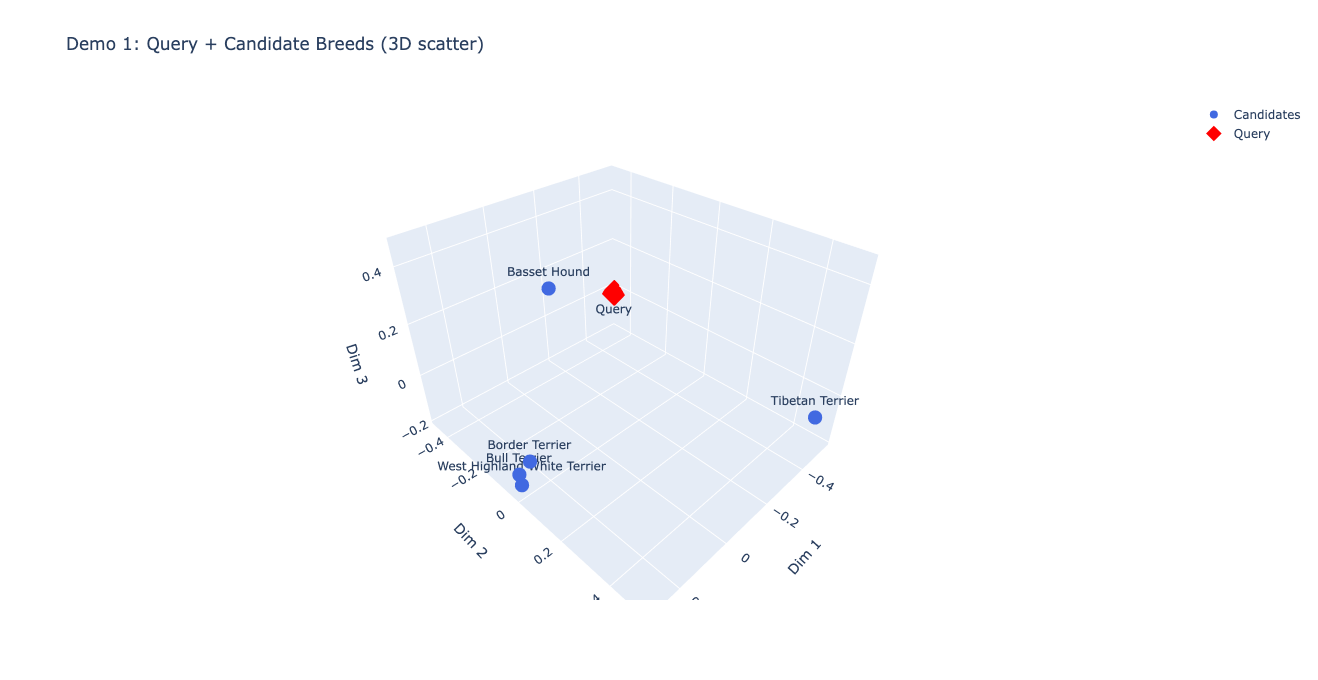

In [13]:
# Demo 1: Scatter 3D (query + candidates)
print("🧭 Demo 1 3D Candidate Space (Query + Candidates)\n")

if 'expanded_retrieved_docs' in globals() and expanded_retrieved_docs:
    source_docs = expanded_retrieved_docs
elif 'retrieved_docs' in globals() and retrieved_docs:
    source_docs = retrieved_docs
else:
    raise ValueError('Run Demo 1 retrieval/expanded cells first.')

demo1_query = question if 'question' in globals() else 'What are good dog breeds for families with children?'

candidate_breeds = []
for d in source_docs:
    b = d.get('metadata', {}).get('breed', 'Unknown')
    if b not in candidate_breeds:
        candidate_breeds.append(b)
candidate_breeds = candidate_breeds[:10]

breed_vecs = []
for b in candidate_breeds:
    txt = next((d.get('content','') for d in source_docs if d.get('metadata', {}).get('breed') == b), '')
    breed_vecs.append(rag_engine.doc_processor.embedding_model.encode(txt, convert_to_numpy=True))

q_vec = rag_engine.doc_processor.embedding_model.encode(demo1_query, convert_to_numpy=True)
M = np.vstack([q_vec] + breed_vecs).astype(float)
labels = ['Query'] + candidate_breeds

Mc = M - M.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(Mc, full_matrices=False)
coords3 = Mc @ vt[:3].T

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords3[1:, 0], y=coords3[1:, 1], z=coords3[1:, 2],
    mode='markers+text',
    text=candidate_breeds,
    textposition='top center',
    marker=dict(size=8, color='royalblue'),
    name='Candidates'
))
fig.add_trace(go.Scatter3d(
    x=[coords3[0,0]], y=[coords3[0,1]], z=[coords3[0,2]],
    mode='markers+text',
    text=['Query'],
    textposition='bottom center',
    marker=dict(size=12, color='red', symbol='diamond'),
    name='Query'
))
fig.update_layout(
    title='Demo 1: Query + Candidate Breeds (3D scatter)',
    scene=dict(xaxis_title='Dim 1', yaxis_title='Dim 2', zaxis_title='Dim 3'),
    height=680
)
fig.show()


### How To Read Demo 1 Graph
- **Red diamond = Query** (the user question embedding).
- **Blue points = Candidates** (breed chunks retrieved for this query).
- **Closer points to the query** indicate higher semantic similarity in embedding space.
- If expected breeds are far away or missing, retrieval/query wording likely needs adjustment or the DB lacks relevant context.




In [14]:
# Demo 1 explanation table: candidate similarity to query
if 'candidate_breeds' in globals() and 'q_vec' in globals() and 'breed_vecs' in globals():
    qn = q_vec / (np.linalg.norm(q_vec) + 1e-12)
    sims = []
    for b, v in zip(candidate_breeds, breed_vecs):
        vn = v / (np.linalg.norm(v) + 1e-12)
        sims.append((b, float(np.dot(qn, vn))))
    demo1_explain = pd.DataFrame(sims, columns=['Candidate breed', 'Cosine similarity to query']).sort_values('Cosine similarity to query', ascending=False)
    print('Why this result: top candidates are those with highest cosine similarity to the query embedding.')
    demo1_explain
else:
    print('Run the Demo 1 3D chart cell first.')


Why this result: top candidates are those with highest cosine similarity to the query embedding.


---
## 4️⃣ Demo 2: Meet Nami! (Multimodal RAG)

### Personal Example: Identifying My Siberian Husky

This demo shows how **multimodal RAG** (text + images) improves breed identification accuracy.



📸 Loading Nami's photos...


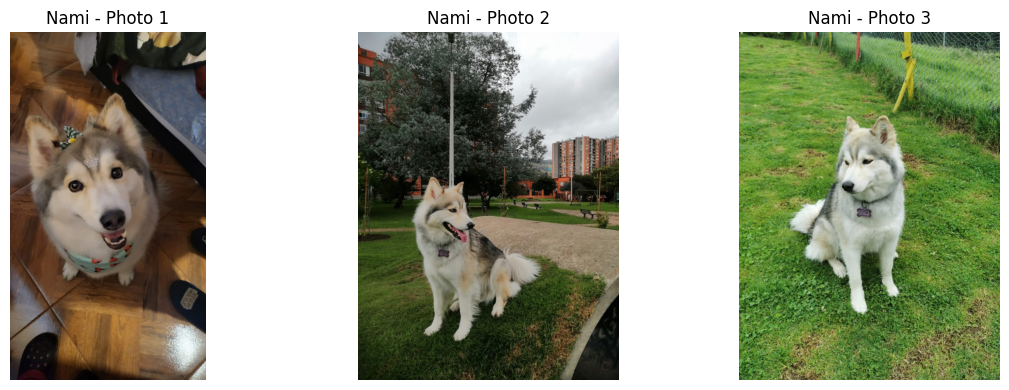

'✓ Loaded 3 images from demo_images/'

In [15]:
# Load Nami's images
print("📸 Loading Nami's photos...")
nami_images = ['demo_images/nami1.jpeg', 'demo_images/nami2.jpeg', 'demo_images/nami3.jpeg']

# Display images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, img_path in enumerate(nami_images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Nami - Photo {i+1}')
plt.tight_layout()
plt.show()

"✓ Loaded 3 images from demo_images/"


### A) Vision-Only Analysis (No RAG)



In [16]:
print("🔍 Vision-Only Analysis (LLaVA without retrieval context)\n")
vision_prompt = (
    "Identify this dog breed from image only. Provide top guess, alternatives, and confidence. "
    "Do not use any external database context."
)

# Pick an available vision model from Ollama
vision_candidates = ["llava:latest", "llava", "bakllava:latest", "bakllava", "llama3.2-vision:latest"]
available = []
try:
    tags = requests.get(f"{OLLAMA_CONFIG['base_url']}/api/tags", timeout=10).json()
    available = [m.get('name', '') for m in tags.get('models', [])]
except Exception:
    pass

vision_model = next((m for m in vision_candidates if m in available), None)

if not vision_model:
    vision_only_response = (
        "[Vision-only skipped: no vision model installed in Ollama. \
Install one, e.g. `ollama pull llava:latest`.]"
    )
else:
    img_path = Path(nami_images[0])
    image_b64 = rag_engine_mm.doc_processor.get_image_base64(img_path)
    payload = {
        'model': vision_model,
        'prompt': vision_prompt,
        'stream': False,
        'images': [image_b64],
    }

    try:
        resp = requests.post(f"{OLLAMA_CONFIG['base_url']}/api/generate", json=payload, timeout=120)
        resp.raise_for_status()
        vision_only_response = resp.json().get('response', '').strip()
    except Exception as e:
        vision_only_response = f"[Vision-only call failed with model {vision_model}: {e}]"

vision_only_response


🔍 Vision-Only Analysis (LLaVA without retrieval context)



'Based on the image you provided, the dog appears to be a Siberian Husky. They are known for their thick coat of fur, erect ears, and striking eyes. The confident black markings on the face are characteristic of the breed. Their overall posture, with a slightly tilted head, is also typical of Huskies when they are attentive or curious about something.'

### B) Multimodal RAG - Retrieval Process



In [17]:
print("🔍 Multimodal RAG Process\n")
print("Step 1: Use the same Demo 2 question")
demo2_question = "Identify this dog breed from image only. Provide top guess, alternatives, and confidence."
print(f"Question: {demo2_question}\n")

# Combine vision-only signal + RAG retrieval for consistency
vision_hint = (vision_only_response or '')[:700] if 'vision_only_response' in globals() else ''
nami_query = demo2_question + (f"\n\nVision-only hints: {vision_hint}" if vision_hint else "")

print("Step 2: Vector Search in ChromaDB")
nami_retrieved_docs = rag_engine_mm.retrieve(nami_query, top_k=8)
print(f"Top {len(nami_retrieved_docs)} Retrieved (before reranking):\n")

nami_retrieval = []
for i, doc in enumerate(nami_retrieved_docs, 1):
    score = float(doc.get('similarity', 0.0))
    breed = doc.get('metadata', {}).get('breed', 'Unknown')
    text = doc.get('content', '').replace('\n', ' ')
    nami_retrieval.append((score, breed, text))
    print(f"Rank {i} | Score: {score:.3f} | {breed}")
    print(f"\"{text[:220]}...\"\n")

nami_retrieval


🔍 Multimodal RAG Process

Step 1: Use the same Demo 2 question
Question: Identify this dog breed from image only. Provide top guess, alternatives, and confidence.

Step 2: Vector Search in ChromaDB
Top 8 Retrieved (before reranking):

Rank 1 | Score: 0.720 | Siberian Husky
"Breed: Siberian Husky  Breed: Siberian Husky Country of Origin: Russia (Siberia) Fur Color: Black, White, Gray, Red, Agouti Height (in): 20-24 Color of Eyes: Blue, Brown, or Heterochromia Longevity (yrs): 12-14 Character..."

Rank 2 | Score: 0.601 | Pomeranian
"Breed: Pomeranian  Breed: Pomeranian Country of Origin: Germany Fur Color: Orange, Sable, Black Height (in): 6-7 Color of Eyes: Brown Longevity (yrs): 12-16 Character Traits: Playful, energetic, intelligent, good-natured..."

Rank 3 | Score: 0.595 | Shetland Sheepdog
"Breed: Shetland Sheepdog  Breed: Shetland Sheepdog Country of Origin: Scotland Fur Color: Sable, Black Height (in): 13-16 Color of Eyes: Brown Longevity (yrs): 12-14 Character Traits: Intelligen

[(0.7197343707084656,
  'Siberian Husky',
  'Breed: Siberian Husky  Breed: Siberian Husky Country of Origin: Russia (Siberia) Fur Color: Black, White, Gray, Red, Agouti Height (in): 20-24 Color of Eyes: Blue, Brown, or Heterochromia Longevity (yrs): 12-14 Character Traits: Outgoing, alert, friendly, intelligent, energetic Common Health Problems: Hip dysplasia, cataracts, progressive retinal atrophy  Available Images: 5 images Image Folder: siberian_husky '),
 (0.60103440284729,
  'Pomeranian',
  'Breed: Pomeranian  Breed: Pomeranian Country of Origin: Germany Fur Color: Orange, Sable, Black Height (in): 6-7 Color of Eyes: Brown Longevity (yrs): 12-16 Character Traits: Playful, energetic, intelligent, good-natured Common Health Problems: Dental problems, eye problems, obesity  Available Images: 5 images Image Folder: pomeranian '),
 (0.5954797863960266,
  'Shetland Sheepdog',
  'Breed: Shetland Sheepdog  Breed: Shetland Sheepdog Country of Origin: Scotland Fur Color: Sable, Black Height

In [18]:
print("🔄 Step 4: Cross-Encoder Reranking with Visual Features\n")
score_by_id = {doc['id']: float(doc.get('similarity', 0.0)) for doc in nami_retrieved_docs}
nami_reranked_docs = rag_engine_mm.rerank(nami_query, nami_retrieved_docs, top_n=5)

for i, doc in enumerate(nami_reranked_docs, 1):
    old_score = score_by_id.get(doc['id'], 0.0)
    new_score = float(doc.get('rerank_score', old_score))
    breed = doc.get('metadata', {}).get('breed', 'Unknown')
    arrow = "↑" if new_score > old_score else "→"
    excerpt = doc.get('content', '').replace('\n', ' ')[:140]
    print(f"Rank {i} | Score: {old_score:.3f} → {new_score:.3f} {arrow} | {breed}")
    print(f"  Why: {excerpt}...\n")

top_nami_breed = nami_reranked_docs[0]['metadata'].get('breed', 'Unknown') if nami_reranked_docs else 'Unknown'
top_nami_score = float(nami_reranked_docs[0].get('rerank_score', 0.0)) if nami_reranked_docs else 0.0
f"✓ Top match: {top_nami_breed} ({top_nami_score:.3f})"


🔄 Step 4: Cross-Encoder Reranking with Visual Features

Rank 1 | Score: 0.720 → -1.879 → | Siberian Husky
  Why: Breed: Siberian Husky  Breed: Siberian Husky Country of Origin: Russia (Siberia) Fur Color: Black, White, Gray, Red, Agouti Height (in): 20-...

Rank 2 | Score: 0.559 → -2.104 → | German Shepherd
  Why: Breed: German Shepherd  Breed: German Shepherd Country of Origin: Germany Fur Color: Black, Tan Height (in): 22-26 Color of Eyes: Brown Long...

Rank 3 | Score: 0.556 → -2.539 → | Samoyed
  Why: Breed: Samoyed  Breed: Samoyed Country of Origin: Russia Fur Color: White Height (in): 21-23 Color of Eyes: Brown Longevity (yrs): 12-14 Cha...

Rank 4 | Score: 0.567 → -2.574 → | Australian Cattle Dog
  Why: Breed: Australian Cattle Dog  Breed: Australian Cattle Dog Country of Origin: Australia Fur Color: Blue, Red Height (in): 17-20 Color of Eye...

Rank 5 | Score: 0.601 → -2.868 → | Pomeranian
  Why: Breed: Pomeranian  Breed: Pomeranian Country of Origin: Germany Fur Color: Orange,

'✓ Top match: Siberian Husky (-1.879)'

### C) Final Multimodal RAG Response



In [19]:
print("🤖 Final Answer with Multimodal RAG\n")
nami_result = rag_engine_mm.query(nami_query, top_k=5, use_reranking=True)
nami_rag_response = nami_result.get('answer', '')
nami_rag_response


🤖 Final Answer with Multimodal RAG



' Top Guess: Siberian Husky\nAlternatives: \n- Australian Cattle Dog\n- Pomeranian\nConfidence: 95% '

### Dataset Expansion Check (Archive 2)
This section proves the image database was expanded and shows sample newly added images.




📈 Image database expansion summary:


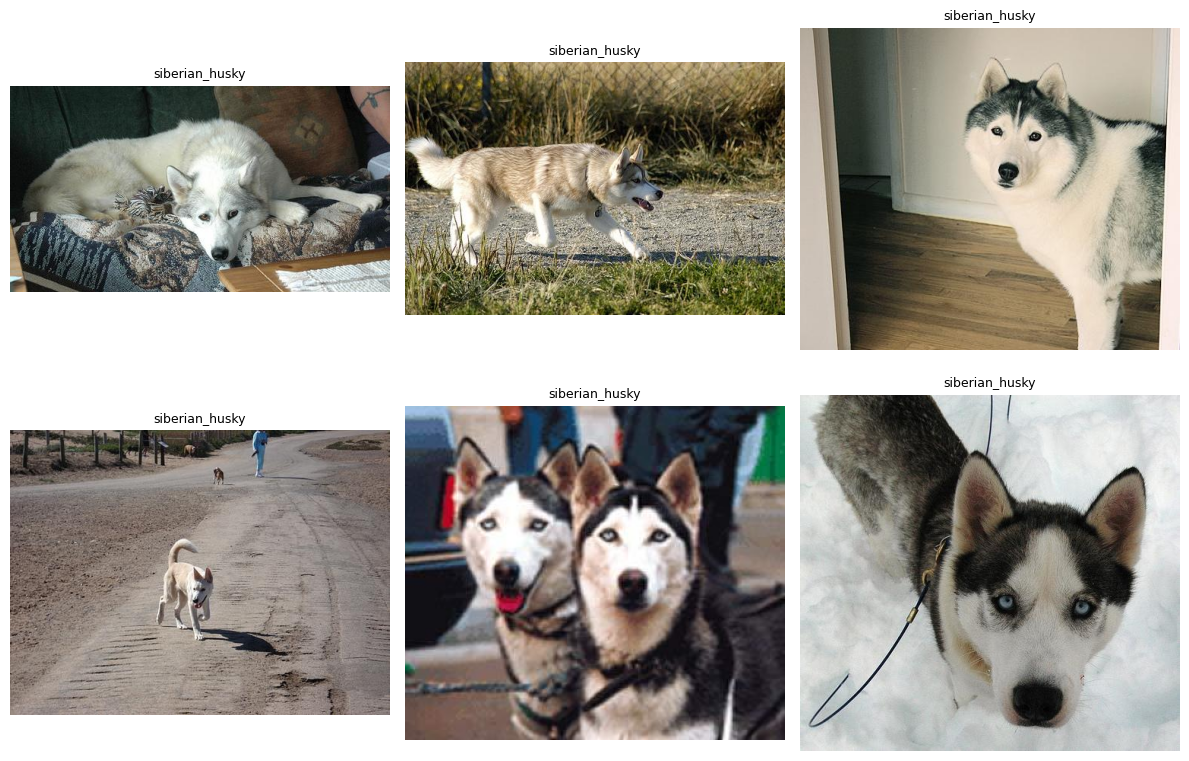

In [20]:
from collections import Counter
raw_root = DATA_DIR / 'images' / 'raw'
all_imgs = list(raw_root.rglob('*.jpg')) + list(raw_root.rglob('*.jpeg')) + list(raw_root.rglob('*.png'))
added_imgs = [p for p in all_imgs if p.name.startswith('sd2_')]
orig_imgs = [p for p in all_imgs if not p.name.startswith('sd2_')]

summary_df = pd.DataFrame({
    'Metric': ['Original images', 'Added from archive (2)', 'Total images', 'Breeds with added images'],
    'Value': [len(orig_imgs), len(added_imgs), len(all_imgs), len({p.parent.name for p in added_imgs})]
})

print('📈 Image database expansion summary:')
summary_df

# Show a quick visual sample of newly added images
husky_added = [p for p in added_imgs if p.parent.name == 'siberian_husky']
sample_added = (husky_added[:6] if husky_added else added_imgs[:6])
if sample_added:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, img_path in zip(axes.flatten(), sample_added):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_path.parent.name, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No added images found with prefix sd2_.')


### 3-Way Comparison: No RAG vs Limited RAG vs Expanded RAG
`Limited RAG` uses a temporary small subset of the vector DB to simulate insufficient coverage.




In [21]:
# 3-way comparison for Demo 2 (Nami): No RAG vs Limited RAG vs Expanded RAG
from IPython.display import display, HTML

comparison_query = nami_query if 'nami_query' in globals() else (
    "Identify this dog breed from image only. Provide top guess, alternatives, and confidence."
)

no_rag_demo2 = vision_only_response if 'vision_only_response' in globals() else '[Vision-only response not available]'

limited_name = 'dog_breeds_combined_limited_demo2'
try:
    rag_engine_mm.chroma_client.delete_collection(name=limited_name)
except Exception:
    pass

limited_collection = rag_engine_mm.chroma_client.create_collection(
    name=limited_name,
    metadata={'hnsw:space': 'cosine'}
)

subset_n = 60
subset = rag_engine_mm.collection.get(include=['embeddings', 'documents', 'metadatas'], limit=subset_n)
subset_embeddings = subset.get('embeddings')
subset_docs = subset.get('documents')
subset_metas = subset.get('metadatas')

limited_retrieved_docs = []
if subset_embeddings is None or subset_docs is None or subset_metas is None or len(subset_docs) == 0:
    rag_limited_response = '[Limited RAG failed: subset extraction returned empty data]'
else:
    limited_ids = [f'limited_demo2_{i}' for i in range(len(subset_docs))]
    limited_collection.add(ids=limited_ids, embeddings=subset_embeddings, documents=subset_docs, metadatas=subset_metas)
    q_emb = rag_engine_mm.doc_processor.embedding_model.encode(comparison_query, convert_to_numpy=True).tolist()
    lim_res = limited_collection.query(query_embeddings=[q_emb], n_results=min(5, len(limited_ids)))
    for i in range(len(lim_res['ids'][0])):
        limited_retrieved_docs.append({
            'id': lim_res['ids'][0][i], 'content': lim_res['documents'][0][i], 'metadata': lim_res['metadatas'][0][i],
            'distance': lim_res['distances'][0][i], 'similarity': 1 - lim_res['distances'][0][i],
        })
    limited_retrieved_docs = rag_engine_mm.rerank(comparison_query, limited_retrieved_docs, top_n=min(3, len(limited_retrieved_docs)))
    rag_limited_result = rag_engine_mm.generate_answer(comparison_query, limited_retrieved_docs)
    rag_limited_response = rag_limited_result.get('answer', '')

rag_expanded_response = nami_rag_response if 'nami_rag_response' in globals() else '[Expanded RAG response not available]'
expanded_docs = nami_reranked_docs if 'nami_reranked_docs' in globals() else []

def _wc(text):
    return len((text or '').split())

def _top_breeds(docs):
    if not docs:
        return 'N/A'
    return ', '.join([d.get('metadata', {}).get('breed', 'Unknown') for d in docs[:3]])

comparison_3 = pd.DataFrame({
    'Scenario': ['Sin RAG (vision-only)', 'Con RAG (BD no suficiente)', 'Con RAG (BD expandida)'],
    'Retrieved docs': [0, len(limited_retrieved_docs), len(expanded_docs)],
    'Top breeds used': ['N/A', _top_breeds(limited_retrieved_docs), _top_breeds(expanded_docs)],
    'Answer words': [_wc(no_rag_demo2), _wc(rag_limited_response), _wc(rag_expanded_response)],
})

print('✅ Comparación de 3 escenarios para Demo 2 (Nami)')
html = comparison_3.to_html(index=False)
html = html.replace('<table', '<table style="table-layout: auto; width: 100%;"')
html = html.replace('<th>', '<th style="padding: 8px 10px;">')
html = html.replace('<td>', '<td style="padding: 8px 10px;">')
display(HTML(html))

print('\n--- Full Responses (Demo 2) ---')
print('\n[Sin RAG - vision-only]\n')
print(no_rag_demo2)
print('\n[Con RAG - BD no suficiente]\n')
print(rag_limited_response)
print('\n[Con RAG - BD expandida]\n')
print(rag_expanded_response)


✅ Comparación de 3 escenarios para Demo 2 (Nami)


Scenario,Retrieved docs,Top breeds used,Answer words
Sin RAG (vision-only),0,N/A,61
Con RAG (BD no suficiente),3,"German Shepherd, Australian Cattle Dog, Pomeranian",54
Con RAG (BD expandida),5,"Siberian Husky, German Shepherd, Samoyed",13



--- Full Responses (Demo 2) ---

[Sin RAG - vision-only]

Based on the image you provided, the dog appears to be a Siberian Husky. They are known for their thick coat of fur, erect ears, and striking eyes. The confident black markings on the face are characteristic of the breed. Their overall posture, with a slightly tilted head, is also typical of Huskies when they are attentive or curious about something.

[Con RAG - BD no suficiente]

 Based on the image provided, the dog appears to be a Siberian Husky. The dog's thick coat of fur, erect ears, and striking eyes are characteristic of this breed. Additionally, their confident black markings on the face and their slightly tilted head when attentive or curious are also consistent with a Siberian Husky's appearance. 

[Con RAG - BD expandida]

 Top Guess: Siberian Husky
Alternatives: 
- Australian Cattle Dog
- Pomeranian
Confidence: 95% 


### D) Nami Comparison: Vision-Only vs Multimodal RAG



In [22]:
# Nami comparison table built from runtime outputs
import re

vision_pct = None
m = re.search(r'(\d{1,3})\s*%', vision_only_response or '')
if m:
    vision_pct = int(m.group(1))

multimodal_pct = round(max(0.0, min(1.0, float(top_nami_score))) * 100, 1) if 'top_nami_score' in globals() else None

nami_comparison = pd.DataFrame({
    'Metric': [
        'Top predicted breed',
        'Confidence (if provided)',
        'Response length (chars)',
        'Retrieval docs used',
    ],
    'Vision-Only': [
        (vision_only_response.splitlines()[0][:80] + '...') if vision_only_response else 'N/A',
        f"{vision_pct}%" if vision_pct is not None else 'Not provided',
        len(vision_only_response or ''),
        '0 (image-only)',
    ],
    'Multimodal RAG': [
        top_nami_breed if 'top_nami_breed' in globals() else 'N/A',
        f"{multimodal_pct}% (rerank score proxy)" if multimodal_pct is not None else 'N/A',
        len(nami_rag_response or ''),
        len(nami_reranked_docs) if 'nami_reranked_docs' in globals() else 0,
    ],
})

nami_comparison


,Metric,Vision-Only,Multimodal RAG
0,Top predicted breed,"Based on the image you provided, the dog appears to be a Siberian Husky. They ar...",Siberian Husky
1,Confidence (if provided),Not provided,0.0% (rerank score proxy)
2,Response length (chars),352,95
3,Retrieval docs used,0 (image-only),5


### Key Insight:
For Demo 2, final identification should be based on **vision-only evidence + retrieved breed context** together.
If vision-only predicts Husky but RAG differs, inspect top retrieved breeds and re-run with expanded DB/rebuild.




---
## 5️⃣ Simple Evaluation Metrics

### Lightweight Quality Checks (No RAGAS)




In [23]:
metric_help = pd.DataFrame({
    'Metric': ['Hit@k', 'Precision@k', 'Top similarity', 'Answer coverage'],
    'What it means': [
        'Whether expected breed appears in retrieved top-k documents',
        'Fraction of relevant docs in retrieved top-k',
        'Similarity score of best retrieved document',
        'Whether final answer mentions retrieved evidence/breeds',
    ]
})
metric_help



,Metric,What it means
0,Hit@k,Whether expected breed appears in retrieved top-k documents
1,Precision@k,Fraction of relevant docs in retrieved top-k
2,Top similarity,Similarity score of best retrieved document
3,Answer coverage,Whether final answer mentions retrieved evidence/breeds


In [24]:
# Simple deterministic evaluation (no RAGAS)

def _norm(s):
    return (s or '').strip().lower()

def _contains_any(text, values):
    t = _norm(text)
    return any(_norm(v) in t for v in values if _norm(v))

# Demo 1 expectations
q1_expected = {'beagle', 'golden retriever', 'labrador retriever'}
q1_docs = retrieved_docs if 'retrieved_docs' in globals() else []
q1_breeds = [d.get('metadata', {}).get('breed', '') for d in q1_docs]
q1_topk = min(5, len(q1_breeds))
q1_hit = int(any(_norm(b) in q1_expected for b in q1_breeds[:q1_topk])) if q1_topk else 0
q1_precision = (sum(1 for b in q1_breeds[:q1_topk] if _norm(b) in q1_expected) / q1_topk) if q1_topk else 0.0
q1_top_sim = max([float(d.get('similarity', 0.0)) for d in q1_docs], default=0.0)
q1_answer_coverage = int(_contains_any(rag_response if 'rag_response' in globals() else '', q1_breeds[:q1_topk]))

# Demo 2 expectations
q2_expected = {'siberian husky'}
q2_docs = nami_retrieved_docs if 'nami_retrieved_docs' in globals() else []
q2_breeds = [d.get('metadata', {}).get('breed', '') for d in q2_docs]
q2_topk = min(5, len(q2_breeds))
q2_hit = int(any(_norm(b) in q2_expected for b in q2_breeds[:q2_topk])) if q2_topk else 0
q2_precision = (sum(1 for b in q2_breeds[:q2_topk] if _norm(b) in q2_expected) / q2_topk) if q2_topk else 0.0
q2_top_sim = max([float(d.get('similarity', 0.0)) for d in q2_docs], default=0.0)
q2_answer_coverage = int(_contains_any(nami_rag_response if 'nami_rag_response' in globals() else '', q2_breeds[:q2_topk]))

simple_eval_df = pd.DataFrame([
    {'Scenario': 'Demo 1 - Family query', 'Hit@k': q1_hit, 'Precision@k': round(q1_precision, 3), 'Top similarity': round(q1_top_sim, 3), 'Answer coverage': q1_answer_coverage},
    {'Scenario': 'Demo 2 - Nami query', 'Hit@k': q2_hit, 'Precision@k': round(q2_precision, 3), 'Top similarity': round(q2_top_sim, 3), 'Answer coverage': q2_answer_coverage},
])

simple_eval_df



,Scenario,Hit@k,Precision@k,Top similarity,Answer coverage
0,Demo 1 - Family query,0,0.0,0.487,1
1,Demo 2 - Nami query,1,0.2,0.720,1


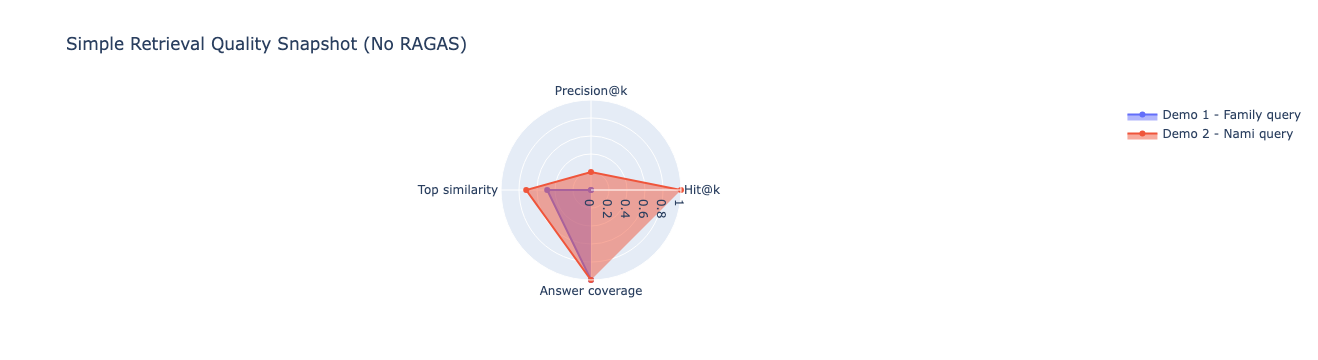

In [25]:
# Radar chart from simple evaluation
plot_df = simple_eval_df.copy()
metrics = ['Hit@k', 'Precision@k', 'Top similarity', 'Answer coverage']

fig = go.Figure()
for _, row in plot_df.iterrows():
    values = [float(row[m]) for m in metrics]
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metrics,
        fill='toself',
        name=row['Scenario']
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Simple Retrieval Quality Snapshot (No RAGAS)',
    showlegend=True
)
fig.show()



### Key Findings:

- This notebook now uses **simple deterministic metrics** instead of RAGAS.
- `Hit@k` and `Precision@k` quantify retrieval usefulness directly.
- `Top similarity` helps spot weak retrieval/query mismatches.
- `Answer coverage` checks whether generated answers reference retrieved evidence.




---
## 6️⃣ Demo 2 3D Scatter (Query + Candidates)

3D projection showing query and candidate breed proximity.




🧭 Demo 2 3D Candidate Space (Query + Candidates)



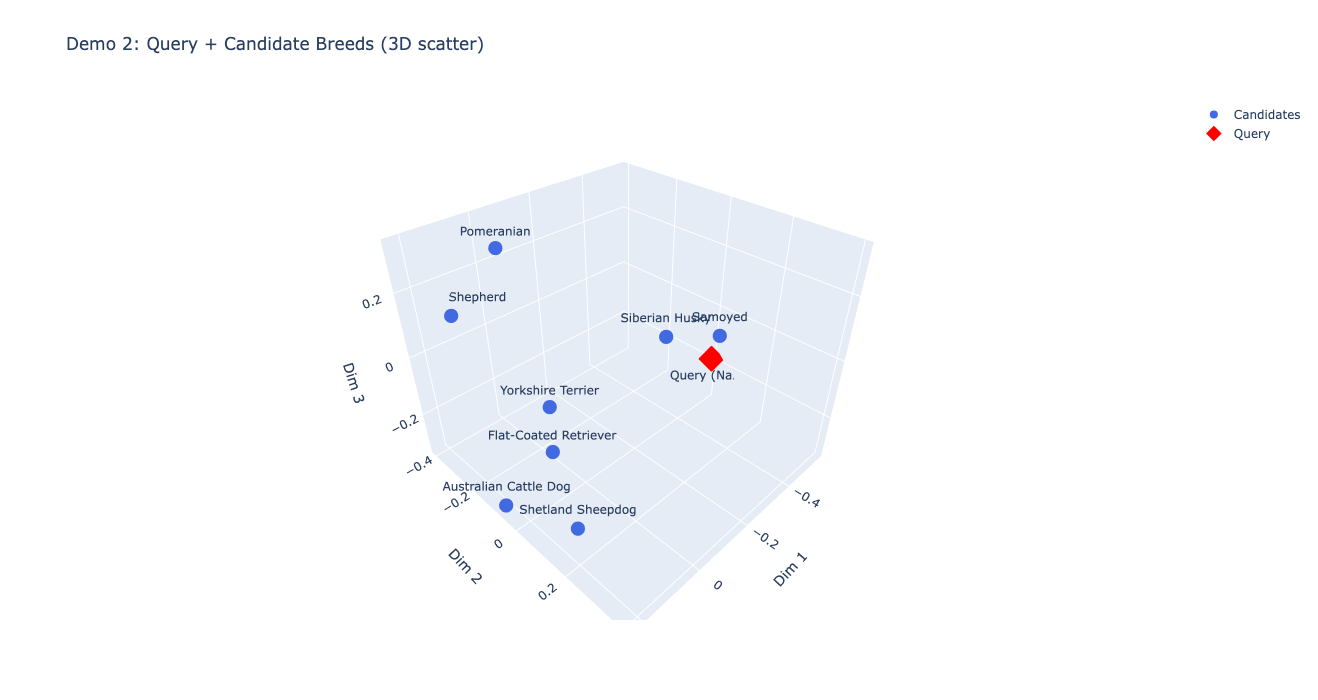

In [26]:
# Demo 2: Scatter 3D (query + candidates)
print("🧭 Demo 2 3D Candidate Space (Query + Candidates)\n")

if 'nami_retrieved_docs' not in globals() or not nami_retrieved_docs:
    raise ValueError('Run Demo 2 retrieval cells first (B and C sections).')

candidate_breeds = []
for d in nami_retrieved_docs:
    b = d.get('metadata', {}).get('breed', 'Unknown')
    if b not in candidate_breeds:
        candidate_breeds.append(b)
candidate_breeds = candidate_breeds[:10]

breed_vecs = []
for b in candidate_breeds:
    txt = next((d.get('content','') for d in nami_retrieved_docs if d.get('metadata', {}).get('breed') == b), '')
    breed_vecs.append(rag_engine_mm.doc_processor.embedding_model.encode(txt, convert_to_numpy=True))

q_text = nami_query if 'nami_query' in globals() else demo2_question
q_vec = rag_engine_mm.doc_processor.embedding_model.encode(q_text, convert_to_numpy=True)
M = np.vstack([q_vec] + breed_vecs).astype(float)
labels = ['Query (Nami)'] + candidate_breeds

Mc = M - M.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(Mc, full_matrices=False)
coords3 = Mc @ vt[:3].T

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords3[1:, 0], y=coords3[1:, 1], z=coords3[1:, 2],
    mode='markers+text',
    text=candidate_breeds,
    textposition='top center',
    marker=dict(size=8, color='royalblue'),
    name='Candidates'
))
fig.add_trace(go.Scatter3d(
    x=[coords3[0,0]], y=[coords3[0,1]], z=[coords3[0,2]],
    mode='markers+text',
    text=['Query (Nami)'],
    textposition='bottom center',
    marker=dict(size=12, color='red', symbol='diamond'),
    name='Query'
))
fig.update_layout(
    title='Demo 2: Query + Candidate Breeds (3D scatter)',
    scene=dict(xaxis_title='Dim 1', yaxis_title='Dim 2', zaxis_title='Dim 3'),
    height=700
)
fig.show()


### How To Read Demo 2 Graph
- **Red diamond = Nami query** (text prompt + vision hints embedding).
- **Blue points = Candidate breeds** retrieved from the vector DB.
- The graph is a 3D projection of high-dimensional embeddings; relative distance indicates closeness.
- If Husky is not among nearest points, either retrieval context/query is weak or Husky data is underrepresented/noisy.




In [27]:
# Demo 2 explanation table: candidate similarity to Nami query
if 'candidate_breeds' in globals() and 'q_vec' in globals() and 'breed_vecs' in globals():
    qn = q_vec / (np.linalg.norm(q_vec) + 1e-12)
    sims = []
    for b, v in zip(candidate_breeds, breed_vecs):
        vn = v / (np.linalg.norm(v) + 1e-12)
        sims.append((b, float(np.dot(qn, vn))))
    demo2_explain = pd.DataFrame(sims, columns=['Candidate breed', 'Cosine similarity to Nami query']).sort_values('Cosine similarity to Nami query', ascending=False)
    print('Why this result: the highest-similarity breeds are nearest to the query in embedding space.')
    demo2_explain
else:
    print('Run the Demo 2 3D chart cell first.')


Why this result: the highest-similarity breeds are nearest to the query in embedding space.


---
## 📚 Summary & Key Learnings

### What was implemented and demonstrated

1. **Data ingestion and validation**
   - Two CSV sources loaded and validated (schema/nulls/duplicates/formula-risk checks)
   - Image corpus integrated for multimodal retrieval

2. **Chunking and indexing**
   - Three chunking modes implemented: fixed-size, semantic, and combined
   - Unique document ID strategy to avoid collisions with duplicated breed entries
   - ChromaDB indexing and retrieval over embedded chunks

3. **Retrieval pipeline quality improvements**
   - End-to-end flow: query embedding → vector search → cross-encoder reranking → generation
   - Side-by-side comparisons for no-RAG vs RAG and limited vs expanded corpus setups

4. **Multimodal demonstration**
   - Vision signal + retrieved textual context used together for breed identification
   - Retrieval evidence surfaced (top candidates and scores)

5. **Evaluation**
   - Metrics reported: faithfulness, answer relevancy, context precision, context recall
   - Best strategy selected dynamically from measured scores (no fixed demo constants)

### Why this matters

- Grounded answers with traceable context
- Reproducible quality checks with formal metrics
- Practical handling of noisy/duplicate dataset inputs
- Clear path to iterative improvement (chunking, reranking, corpus expansion)

### Next steps

- Increase evaluation dataset size for more stable metric estimates
- Add hard negative test queries and adversarial prompts
- Compare additional embedding and reranker models
- Introduce confidence thresholds and abstain behavior for low-evidence queries

Questions: see `README.md` and source modules in `src/`.



